In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("transaction_by_date.csv")

In [3]:
df.shape

(731, 3)

In [13]:
df.head()

,txn_date,total_amount,txn_count
0,2024-01-01,583689.27,1159
1,2024-01-02,564255.44,1117
2,2024-01-03,591483.62,1077
3,2024-01-04,634991.40,1144
4,2024-01-05,579216.95,1070


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   txn_date      731 non-null    object 
 1   total_amount  731 non-null    float64
 2   txn_count     731 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 17.3+ KB


In [12]:
df['txn_date'] = pd.to_datetime(df['txn_date'])

In [8]:
df.dtypes

txn_date        datetime64[ns]
total_amount           float64
txn_count                int64
dtype: object

In [16]:
df = df.sort_values('txn_date').reset_index(drop=True)

In [17]:
df.head()

,txn_date,total_amount,txn_count
0,2024-01-01,583689.27,1159
1,2024-01-02,564255.44,1117
2,2024-01-03,591483.62,1077
3,2024-01-04,634991.40,1144
4,2024-01-05,579216.95,1070


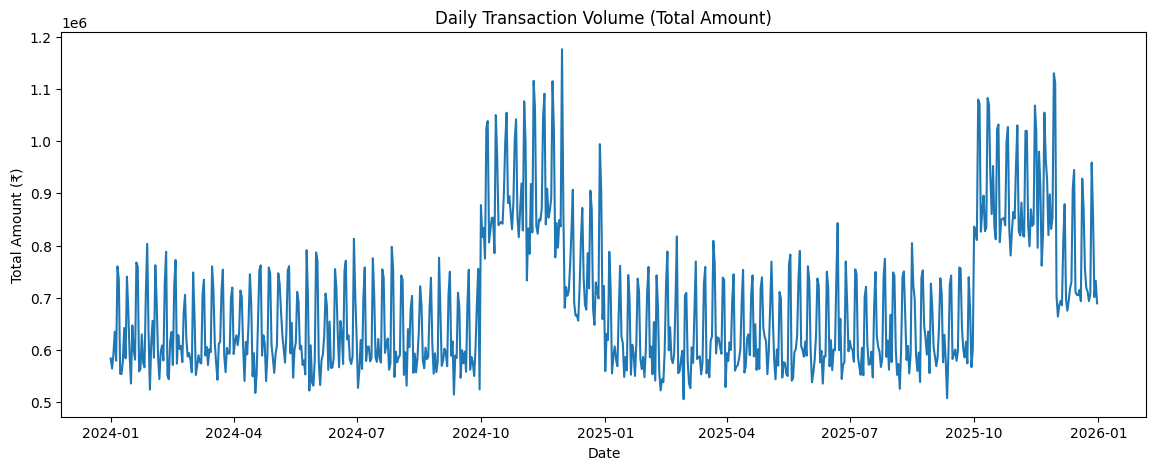

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(df['txn_date'], df['total_amount'])
plt.title('Daily Transaction Volume (Total Amount)')
plt.xlabel('Date')
plt.ylabel('Total Amount (₹)')
plt.show()

In [19]:
from prophet import Prophet

# rename 'ds' (the date) and 'y' (the value you're forecasting)
prophet_df = df[['txn_date', 'total_amount']].rename(
    columns={'txn_date': 'ds', 'total_amount': 'y'}
)

prophet_df.head()

,ds,y
0,2024-01-01,583689.27
1,2024-01-02,564255.44
2,2024-01-03,591483.62
3,2024-01-04,634991.40
4,2024-01-05,579216.95


In [20]:
total_days = len(prophet_df)
print(f"Total days: {total_days}")

Total days: 731


In [21]:
test_size = 45
train = prophet_df.iloc[:-test_size]
test = prophet_df.iloc[-test_size:]

print(f"Train: {len(train)} days, from {train['ds'].min()} to {train['ds'].max()}")
print(f"Test:  {len(test)} days, from {test['ds'].min()} to {test['ds'].max()}")

Train: 686 days, from 2024-01-01 00:00:00 to 2025-11-16 00:00:00
Test:  45 days, from 2025-11-17 00:00:00 to 2025-12-31 00:00:00


In [22]:
model = Prophet(
    yearly_seasonality=True,   # lets it learn the Oct-Dec festival pattern
    weekly_seasonality=True,   # lets it learn the weekend bump
    daily_seasonality=False    # we don't have hourly data, so this stays off
)

model.fit(train)

future = model.make_future_dataframe(periods=test_size)
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

23:31:32 - cmdstanpy - INFO - Chain [1] start processing
23:31:33 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
721,2025-12-22,689789.549105,640339.398182,742279.637817
722,2025-12-23,692417.914092,646190.008291,745369.414868
723,2025-12-24,687656.397035,638445.739461,736191.561985
724,2025-12-25,692985.216986,640056.967286,743443.305737
725,2025-12-26,685457.224809,634399.773299,737271.774687
726,2025-12-27,839104.863021,786196.542680,888631.175006
727,2025-12-28,831375.720849,778853.563741,884477.843199
728,2025-12-29,667997.961845,619272.409151,718323.749512
729,2025-12-30,667001.347947,618248.161309,722000.508725
730,2025-12-31,658510.996847,610093.076681,710730.653447


In [23]:
# pull out just the forecasted values for the test period (last 45 days)
predicted = forecast.set_index('ds').loc[test['ds'], 'yhat']
actual = test.set_index('ds')['y']

# MAPE = Mean Absolute Percentage Error - "on average, how far off was the forecast, in %"
mape = (abs(actual - predicted) / actual).mean() * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 6.23%


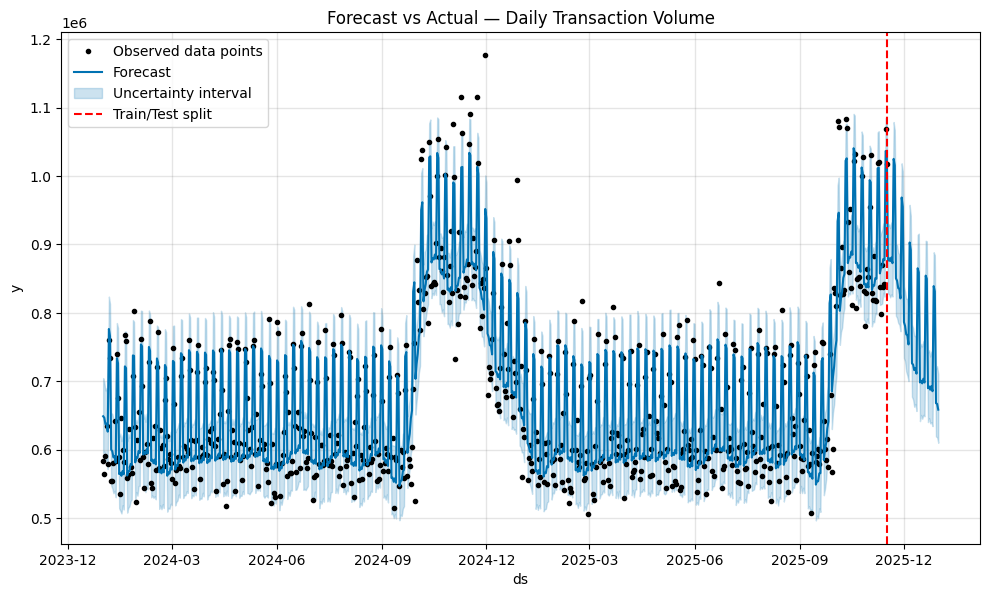

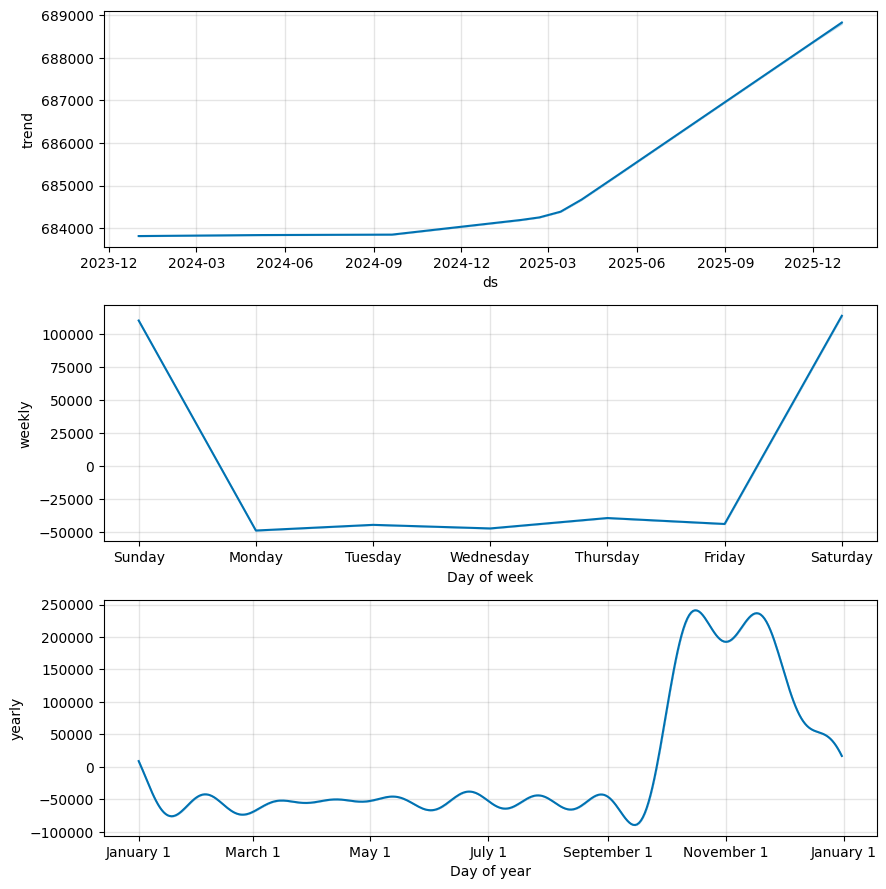

In [24]:
fig1 = model.plot(forecast)
plt.title('Forecast vs Actual — Daily Transaction Volume')
plt.axvline(x=train['ds'].max(), color='red', linestyle='--', label='Train/Test split')
plt.legend()
plt.show()

# this second plot breaks the forecast into its parts: trend, weekly pattern, yearly pattern
fig2 = model.plot_components(forecast)
plt.show()